In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
result_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0411_1805_loth_baker_corrs_30_100")

In [5]:
sc_results = pd.read_parquet(result_dir / "val_scenario_results.parquet")

In [8]:
event = "3528839"
site_int = "CBGS"

cur_sc_results = sc_results[(sc_results["event_id"] == event) & (sc_results["site_int"] == site_int)]

In [9]:
cur_sc_results

,event_id,site_int,rel_id,pSA_0.01_prob,pSA_0.02_prob,pSA_0.03_prob,pSA_0.04_prob,pSA_0.05_prob,pSA_0.075_prob,pSA_0.1_prob,...,pSA_1.25_residual,pSA_1.5_residual,pSA_2.0_residual,pSA_2.5_residual,pSA_3.0_residual,pSA_4.0_residual,pSA_5.0_residual,pSA_6.0_residual,pSA_7.5_residual,pSA_10.0_residual
3528839_CBGS_REL01,3528839,CBGS,REL01,0.002704,0.000655,1.075332e-04,0.000136,0.000302,0.001137,3.310678e-07,...,2.770554,2.653444,1.546066,1.715790,2.012654,1.210223,2.734284,2.657123,1.718464,1.129975
3528839_CBGS_REL02,3528839,CBGS,REL02,0.011392,0.000389,3.473546e-03,0.005252,0.002138,0.037928,3.611399e-04,...,1.011744,1.315043,1.343415,1.146192,1.204227,0.542882,0.974675,0.880250,0.234678,1.551905
3528839_CBGS_REL03,3528839,CBGS,REL03,0.003291,0.107742,4.229058e-02,0.046783,0.014847,0.001573,1.507628e-02,...,1.761755,1.269105,2.051687,1.777551,2.466284,2.482251,2.566406,2.338360,0.244110,0.280658
3528839_CBGS_REL04,3528839,CBGS,REL04,0.000030,0.000012,2.159466e-07,0.000001,0.000022,0.000005,1.507974e-04,...,2.440888,2.704726,2.726064,2.245979,2.899896,1.876079,3.292421,3.664840,2.256539,1.433171
3528839_CBGS_REL05,3528839,CBGS,REL05,0.000164,0.000080,2.683841e-03,0.005017,0.000212,0.000953,4.750396e-05,...,2.032773,1.928069,1.874760,2.258365,1.315853,0.741055,3.004515,2.346293,1.890185,1.464650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3528839_CBGS_REL95,3528839,CBGS,REL95,0.000380,0.000873,1.402173e-04,0.000352,0.000748,0.000045,2.102308e-04,...,1.534279,2.625719,2.297760,2.382247,2.176229,2.179349,3.231709,2.528341,2.036457,1.071988
3528839_CBGS_REL96,3528839,CBGS,REL96,0.000106,0.000017,1.897330e-06,0.000003,0.000326,0.000003,1.022774e-05,...,2.574150,2.801340,2.104403,2.158480,1.441400,1.516846,2.719294,2.377123,2.598097,-0.240382
3528839_CBGS_REL97,3528839,CBGS,REL97,0.008399,0.004293,5.346495e-04,0.000989,0.000461,0.000473,1.075104e-02,...,1.555981,1.820764,1.373264,0.935553,1.146526,2.132720,1.365767,2.174651,1.486650,1.062294
3528839_CBGS_REL98,3528839,CBGS,REL98,0.001170,0.000054,1.486159e-05,0.000018,0.001290,0.000598,1.821402e-04,...,1.468975,2.359865,1.508767,0.418872,1.801443,1.393141,1.884800,1.643065,1.160717,0.833497


In [11]:
cur_im = "pSA_2.0"

cur_df = cur_sc_results[["rel_id", f"{cur_im}_prob", f"{cur_im}_misfit", f"{cur_im}_residual"]]

In [16]:
# Uniform probabilities
prob = np.ones(100) / 100
loss = np.sum(prob * cur_df[f"{cur_im}_misfit"].values)
print("Uniform loss: ", loss)

Uniform loss:  3.7029100693762302


In [18]:
# Lowest loss
min_loss = np.min(cur_df[f"{cur_im}_misfit"].values)
print(f"Lowest loss: {min_loss}")

Lowest loss: 0.2085392326116562


In [19]:
# Model loss
prob = cur_df[f"{cur_im}_prob"].values
loss = np.sum(prob * cur_df[f"{cur_im}_misfit"].values)
print(f"Model loss: {loss}")

Model loss: 1.4381811618804932


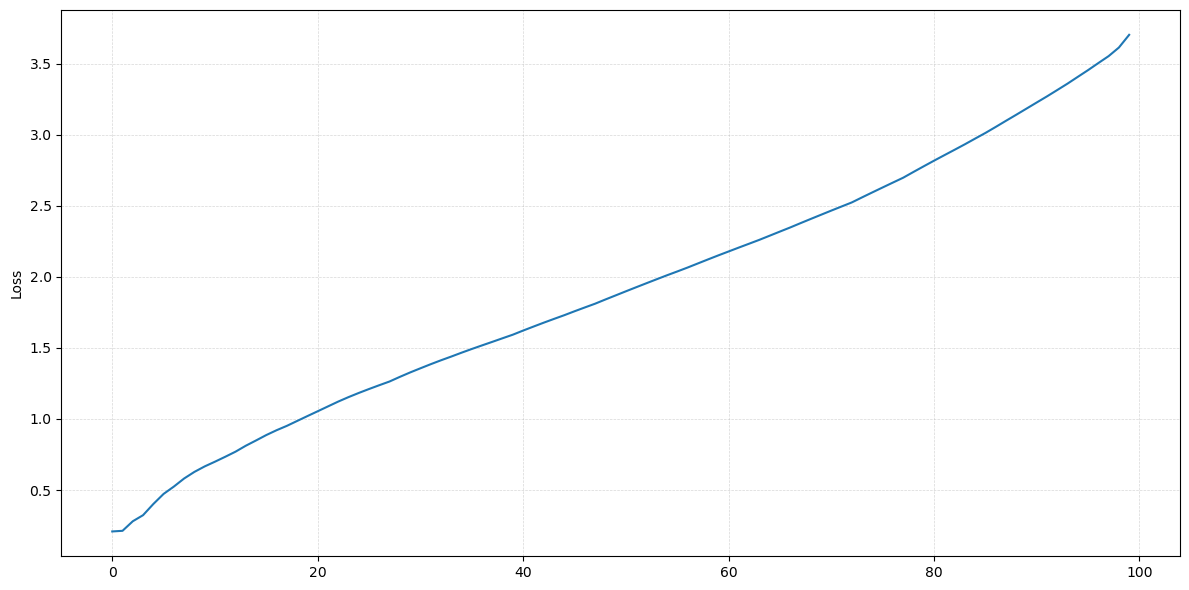

In [21]:
misfit_results = []

for i in range(1, 101):
	cur_prob = np.zeros(100)
	cur_prob[:i] = 1 / i
	cur_misfit = np.sort(cur_df[f"{cur_im}_misfit"].values)
	
	cur_loss = np.sum(cur_prob * cur_misfit)
	misfit_results.append(cur_loss)
	
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(misfit_results)
ax.set_ylabel(f"Loss")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.tight_layout()


In [20]:
np.sort(cur_df[f"{cur_im}_misfit"].values)

array([ 0.20853923,  0.21743083,  0.41477063,  0.45149106,  0.7157408 ,
        0.82835805,  0.8341555 ,  0.97972417,  0.99848735,  1.0128474 ,
        1.0310385 ,  1.1145288 ,  1.1997358 ,  1.3552727 ,  1.3702867 ,
        1.4584633 ,  1.4638333 ,  1.4724152 ,  1.6060963 ,  1.6726042 ,
        1.7323256 ,  1.8047653 ,  1.8709701 ,  1.8756876 ,  1.8858551 ,
        1.9053597 ,  1.9343354 ,  1.9698391 ,  2.2058916 ,  2.2280903 ,
        2.2317355 ,  2.276378  ,  2.2952385 ,  2.3031712 ,  2.3903208 ,
        2.40784   ,  2.4282503 ,  2.467558  ,  2.5301452 ,  2.57291   ,
        2.7794363 ,  2.7892992 ,  2.8325438 ,  2.8467116 ,  2.8771536 ,
        3.0033014 ,  3.0182836 ,  3.051041  ,  3.2576709 ,  3.281718  ,
        3.3452537 ,  3.3805487 ,  3.4256208 ,  3.470272  ,  3.5138505 ,
        3.5147233 ,  3.604153  ,  3.732921  ,  3.786114  ,  3.8214495 ,
        3.8294232 ,  3.8903503 ,  3.9142938 ,  3.9808092 ,  4.1458807 ,
        4.209421  ,  4.247853  ,  4.405038  ,  4.4285135 ,  4.46